In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('df_eda.csv', index_col=0, parse_dates=True)

In [3]:
# Add time helper columns
df['month']  = df.index.month
df['hour']   = df.index.hour
df['year']   = df.index.year
df['season'] = df['month'].map({
    12:'Winter',1:'Winter',2:'Winter',
     3:'Spring',4:'Spring',5:'Spring',
     6:'Summer',7:'Summer',8:'Summer',
     9:'Autumn',10:'Autumn',11:'Autumn'
})

In [4]:
print(f'Rows  : {len(df):,}')
print(f'Period: {df.index.min().date()} to {df.index.max().date()}')
print(f'Nulls : {df.isnull().sum().sum()}  <- should be 0')

Rows  : 37,730
Period: 2004-01-01 to 2006-02-25
Nulls : 0  <- should be 0


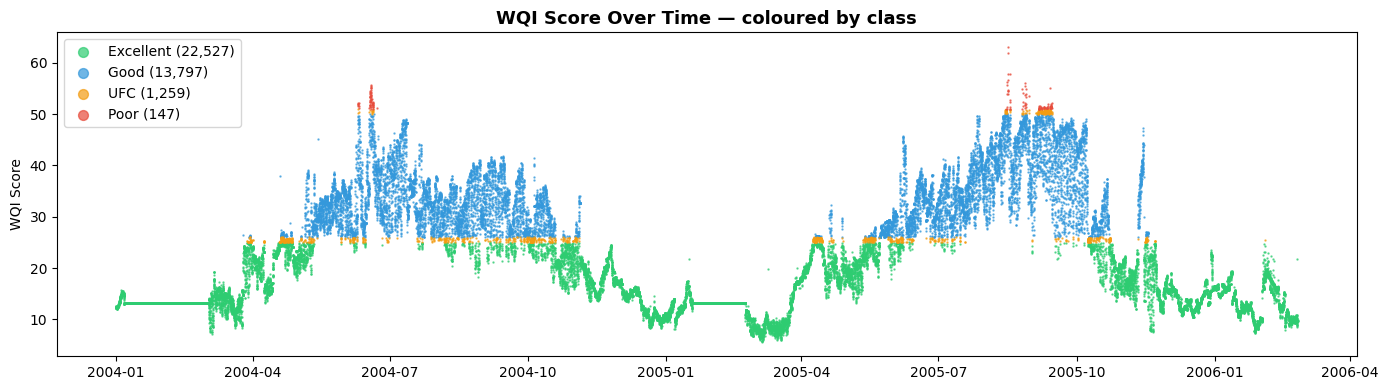

In [5]:
# "WQI follows a clear repeating yearly cycle — high in summer, low in winter."

colors = {'Excellent':'#2ecc71','Good':'#3498db','UFC':'#f39c12','Poor':'#e74c3c'}
fig, ax = plt.subplots(figsize=(14,4))
for cls, col in colors.items():
    mask = df['WQI_Class'] == cls
    ax.scatter(df.index[mask], df['WQI'][mask], s=0.5, color=col,
               label=f'{cls} ({mask.sum():,})', alpha=0.7)

ax.set_title('WQI Score Over Time — coloured by class', fontsize=13, fontweight='bold')
ax.set_ylabel('WQI Score')
ax.legend(markerscale=10, loc='upper left')
plt.tight_layout()
plt.savefig('p1_wqi_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
print('\nClass breakdown:')
for cls, n in df['WQI_Class'].value_counts().items():
    print(f'  {cls:<12} {n:>6,}  ({100*n/len(df):.1f}%)')


Class breakdown:
  Excellent    22,527  (59.7%)
  Good         13,797  (36.6%)
  UFC           1,259  (3.3%)
  Poor            147  (0.4%)


In [7]:
# "Every sensor and WQI peaks in summer and troughs in winter."

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
cols_to_plot = ['Temp','DO_mgl','pH','Turb','Depth','WQI']
monthly      = df.groupby('month')[cols_to_plot].median()

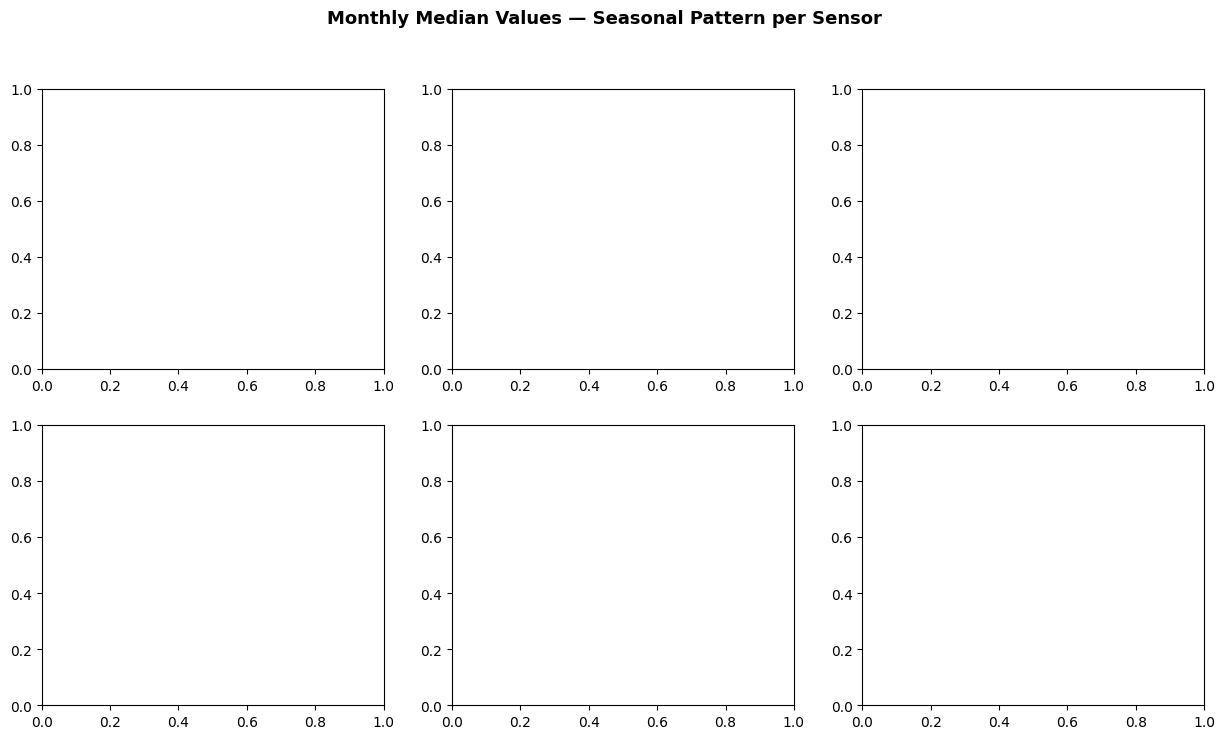

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))
fig.suptitle('Monthly Median Values — Seasonal Pattern per Sensor', fontsize=13, fontweight='bold')
axes = axes.flatten()

In [9]:
for i, col in enumerate(cols_to_plot):
    ax    = axes[i]
    color = '#e74c3c' if col == 'WQI' else '#3498db'
    ax.plot(monthly.index, monthly[col], marker='o', linewidth=2.5, color=color)
    ax.fill_between(monthly.index, monthly[col], alpha=0.15, color=color)
    ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, rotation=45)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Median value')

plt.tight_layout()
plt.savefig('p2_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [10]:
print('WQI by month (median):\n')
for m, v in monthly['WQI'].items():
    bar = '█' * int(v/2)
    print(f'  {month_labels[m-1]}  {v:5.1f}  {bar}')

WQI by month (median):

  Jan   13.2  ██████
  Feb   13.2  ██████
  Mar   12.3  ██████
  Apr   21.4  ██████████
  May   26.3  █████████████
  Jun   31.8  ███████████████
  Jul   34.4  █████████████████
  Aug   35.4  █████████████████
  Sep   36.7  ██████████████████
  Oct   25.1  ████████████
  Nov   18.1  █████████
  Dec   13.6  ██████


Text(0.5, 0.98, 'What Drives WQI?')

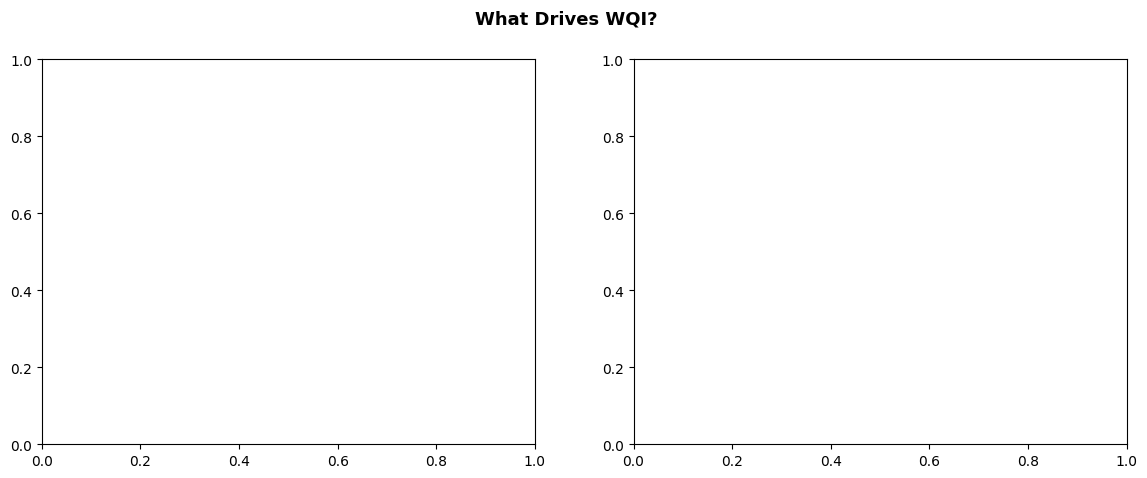

In [11]:
# "Temp (r=+0.86) and DO (r=-0.95) almost fully explain WQI."

sensor_cols   = ['Temp','SpCond','Sal','DO_mgl','Depth','pH','Turb']
corr_with_wqi = df[sensor_cols+['WQI']].corr()['WQI'].drop('WQI').sort_values()

season_colors = {'Winter':'#3498db','Spring':'#2ecc71','Summer':'#e74c3c','Autumn':'#f39c12'}

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('What Drives WQI?', fontsize=13, fontweight='bold')

In [12]:
ax = axes[0]
bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_wqi.values]
bars = ax.barh(corr_with_wqi.index, corr_with_wqi.values, color=bar_colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Correlation with WQI (r)')
ax.set_title('Sensor Correlation with WQI')
for bar, val in zip(bars, corr_with_wqi.values):
    ax.text(val+(0.02 if val>=0 else -0.02), bar.get_y()+bar.get_height()/2,
            f'{val:.2f}', va='center', ha='left' if val>=0 else 'right', fontsize=10)

In [13]:
ax2 = axes[1]
for season, color in season_colors.items():
    mask = df['season'] == season
    ax2.scatter(df.loc[mask,'Temp'], df.loc[mask,'WQI'],
                s=1, alpha=0.3, color=color, label=season)
ax2.set_xlabel('Temperature (°C)'); ax2.set_ylabel('WQI Score')
ax2.set_title(f'Temp vs WQI  (r={corr_with_wqi["Temp"]:.2f})')
ax2.legend(markerscale=8)

In [14]:
plt.tight_layout()
plt.savefig('p3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

Text(0.5, 0.98, 'Diurnal Pattern — How WQI and Temp change by Hour of Day')

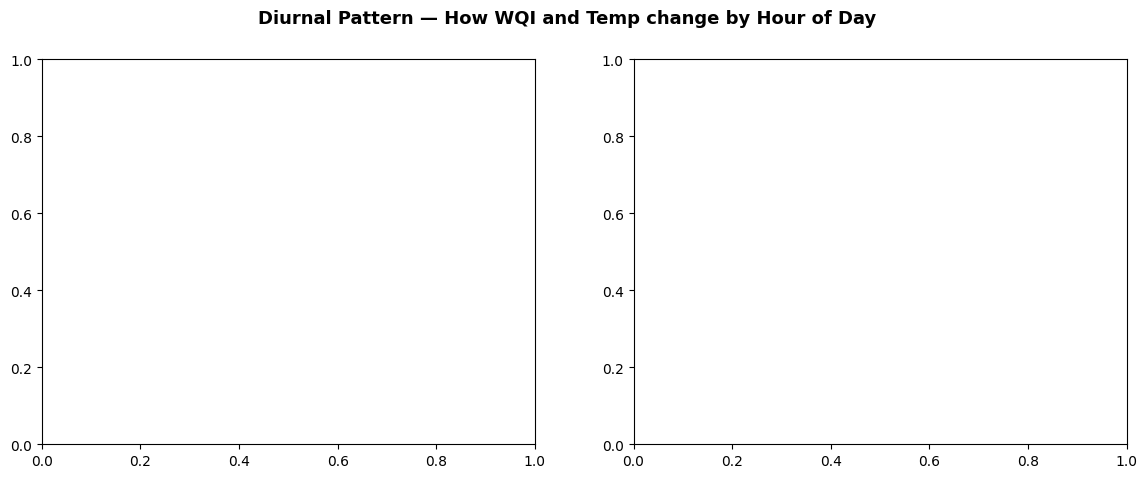

In [15]:
# "WQI and Temp change predictably across 24 hours — strongest in Summer."

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Diurnal Pattern — How WQI and Temp change by Hour of Day',
             fontsize=13, fontweight='bold')

In [16]:
for ax, col in zip(axes, ['WQI','Temp']):
    for season, color in season_colors.items():
        hourly = df[df['season']==season].groupby('hour')[col].median()
        ax.plot(hourly.index, hourly.values, label=season, color=color,
                linewidth=2.5, marker='o', markersize=3)
    ax.set_xlabel('Hour of Day'); ax.set_ylabel(f'Median {col}')
    ax.set_title(f'{col} by Hour — by Season')
    ax.set_xticks([0,6,12,18,23]); ax.legend()

plt.tight_layout()
plt.savefig('p4_diurnal.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

Text(0.5, 0.98, 'WQI Class Breakdown by Season')

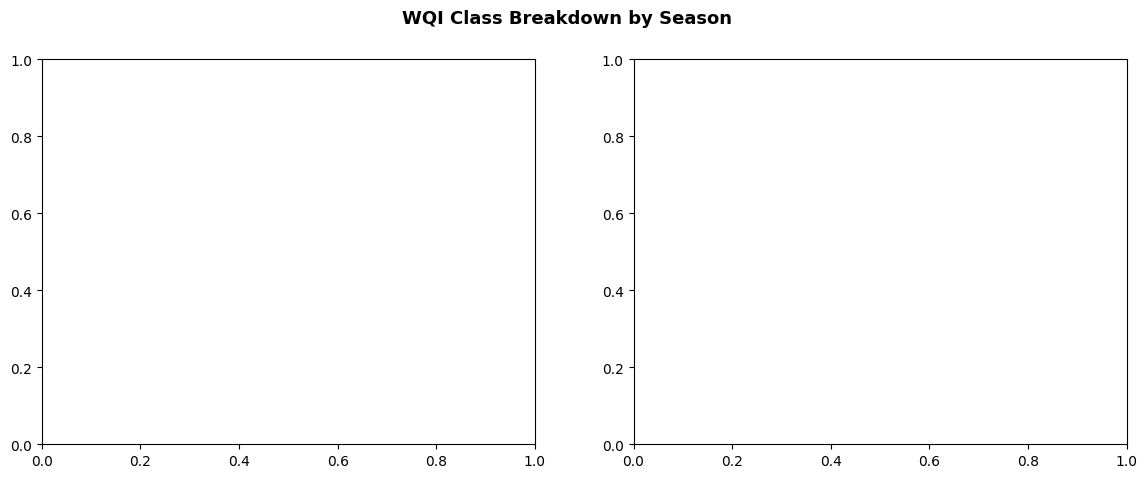

In [17]:
# "In Winter nearly all readings are Excellent. Poor quality only appears in Summer/Autumn."

season_order = ['Winter','Spring','Summer','Autumn']
class_order  = ['Excellent','Good','UFC','Poor']
class_colors = {'Excellent':'#2ecc71','Good':'#3498db','UFC':'#f39c12','Poor':'#e74c3c'}

tbl     = (df.groupby(['season','WQI_Class']).size()
             .unstack(fill_value=0)
             .reindex(season_order)[class_order])
tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('WQI Class Breakdown by Season', fontsize=13, fontweight='bold')

In [18]:
ax = axes[0]
bottom = np.zeros(len(season_order))
x = np.arange(len(season_order))
for cls in class_order:
    ax.bar(x, tbl_pct[cls], bottom=bottom, label=cls, color=class_colors[cls], alpha=0.9)
    bottom += tbl_pct[cls].values
ax.set_xticks(x); ax.set_xticklabels(season_order)
ax.set_ylabel('% of readings'); ax.set_title('WQI Class Share by Season')
ax.legend(loc='lower right')

In [19]:
ax2 = axes[1]
data_by_season = [df[df['season']==s]['WQI'].values for s in season_order]
bp = ax2.boxplot(data_by_season, patch_artist=True,
                 medianprops={'color':'white','linewidth':2})
for patch, season in zip(bp['boxes'], season_order):
    patch.set_facecolor(season_colors[season]); patch.set_alpha(0.8)
ax2.set_xticklabels(season_order)
ax2.set_ylabel('WQI Score'); ax2.set_title('WQI Score Distribution by Season')

Text(0.5, 1.0, 'WQI Score Distribution by Season')

In [21]:
plt.tight_layout()
plt.savefig('p5_class_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nWQI Class % by Season:')
print(tbl_pct.round(1).to_string())

<Figure size 640x480 with 0 Axes>


WQI Class % by Season:
WQI_Class  Excellent  Good  UFC  Poor
season                               
Winter         100.0   0.0  0.0   0.0
Spring          74.8  19.6  5.5   0.0
Summer           4.2  91.2  3.5   1.1
Autumn          48.2  45.9  5.3   0.6


In [23]:
# "12.2% rows were gap-filled. The imputation flags track exactly which ones."

imp_cols      = [c for c in df.columns if 'was_imputed' in c]
df['any_gap'] = df[imp_cols].any(axis=1)

total    = len(df)
imputed  = df['any_gap'].sum()
original = total - imputed

print(f'Total rows      : {total:,}')
print(f'Original rows   : {original:,}  ({100*original/total:.1f}%)')
print(f'Gap-filled rows : {imputed:,}  ({100*imputed/total:.1f}%)')

monthly_gaps = df.groupby('month')['any_gap'].sum()

Total rows      : 37,730
Original rows   : 37,730  (100.0%)
Gap-filled rows : 0  (0.0%)


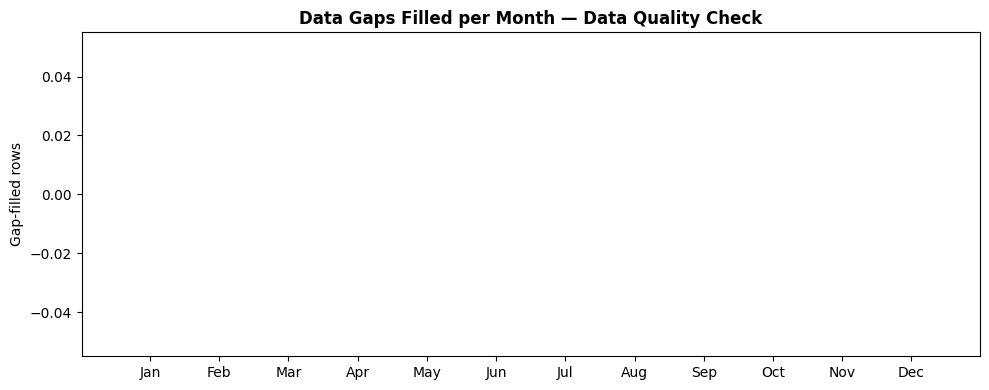

In [25]:

fig, ax = plt.subplots(figsize=(10,4))
ax.bar(monthly_gaps.index, monthly_gaps.values, color='#e74c3c', alpha=0.75)
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels)
ax.set_ylabel('Gap-filled rows')
ax.set_title('Data Gaps Filled per Month — Data Quality Check', fontweight='bold')
plt.tight_layout()
plt.savefig('p6_data_quality.png', dpi=150, bbox_inches='tight')
plt.show()

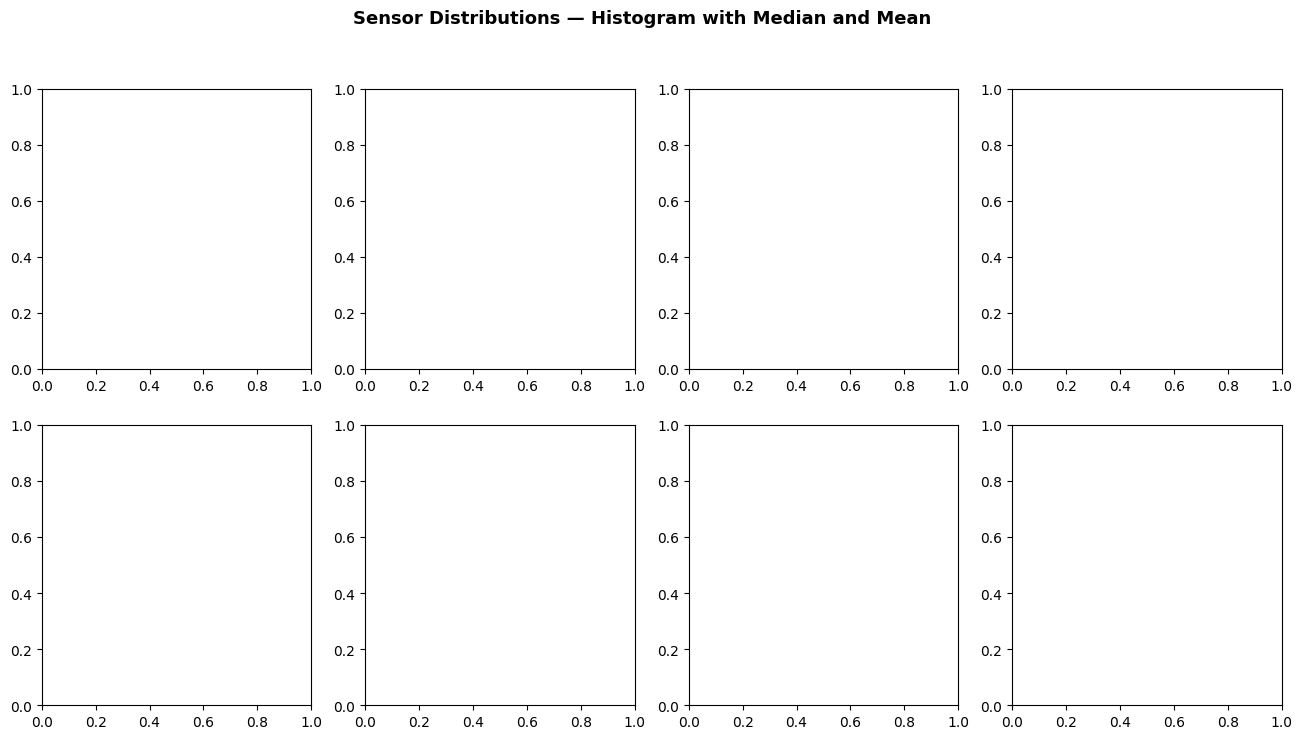

In [26]:
# "Turbidity has extreme events pushing the mean above the median — possible storm events."

all_cols = ['Temp','SpCond','Sal','DO_mgl','Depth','pH','Turb','WQI']

fig, axes = plt.subplots(2, 4, figsize=(16,8))
fig.suptitle('Sensor Distributions — Histogram with Median and Mean',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

In [27]:
for i, col in enumerate(all_cols):
    ax   = axes[i]
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    n_out = ((data < q1-1.5*(q3-q1)) | (data > q3+1.5*(q3-q1))).sum()

    ax.hist(data, bins=50, color='#3498db', alpha=0.75, edgecolor='none')
    ax.axvline(data.median(), color='#2ecc71', linewidth=2, linestyle='--',
               label=f'Median {data.median():.2f}')
    ax.axvline(data.mean(),   color='#e74c3c', linewidth=2, linestyle='-',
               label=f'Mean {data.mean():.2f}')
    ax.set_title(f'{col}  |  {n_out} outliers', fontweight='bold')
    ax.legend(fontsize=8)

In [29]:
plt.tight_layout()
plt.savefig('p7_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSensor stats summary:')
print(df[all_cols].agg(['min','mean','median','max']).T.round(2).to_string())

<Figure size 640x480 with 0 Axes>


Sensor stats summary:
         min   mean  median    max
Temp    0.90  15.09   14.40  32.70
SpCond  0.01   0.17    0.16   0.61
Sal     0.00   0.10    0.10   0.30
DO_mgl  0.20   9.08    9.80  14.80
Depth   0.00   0.32    0.30   1.30
pH      5.50   6.89    6.90   9.60
Turb    0.00   0.02    0.01   2.53
WQI     5.70  23.17   21.10  63.06


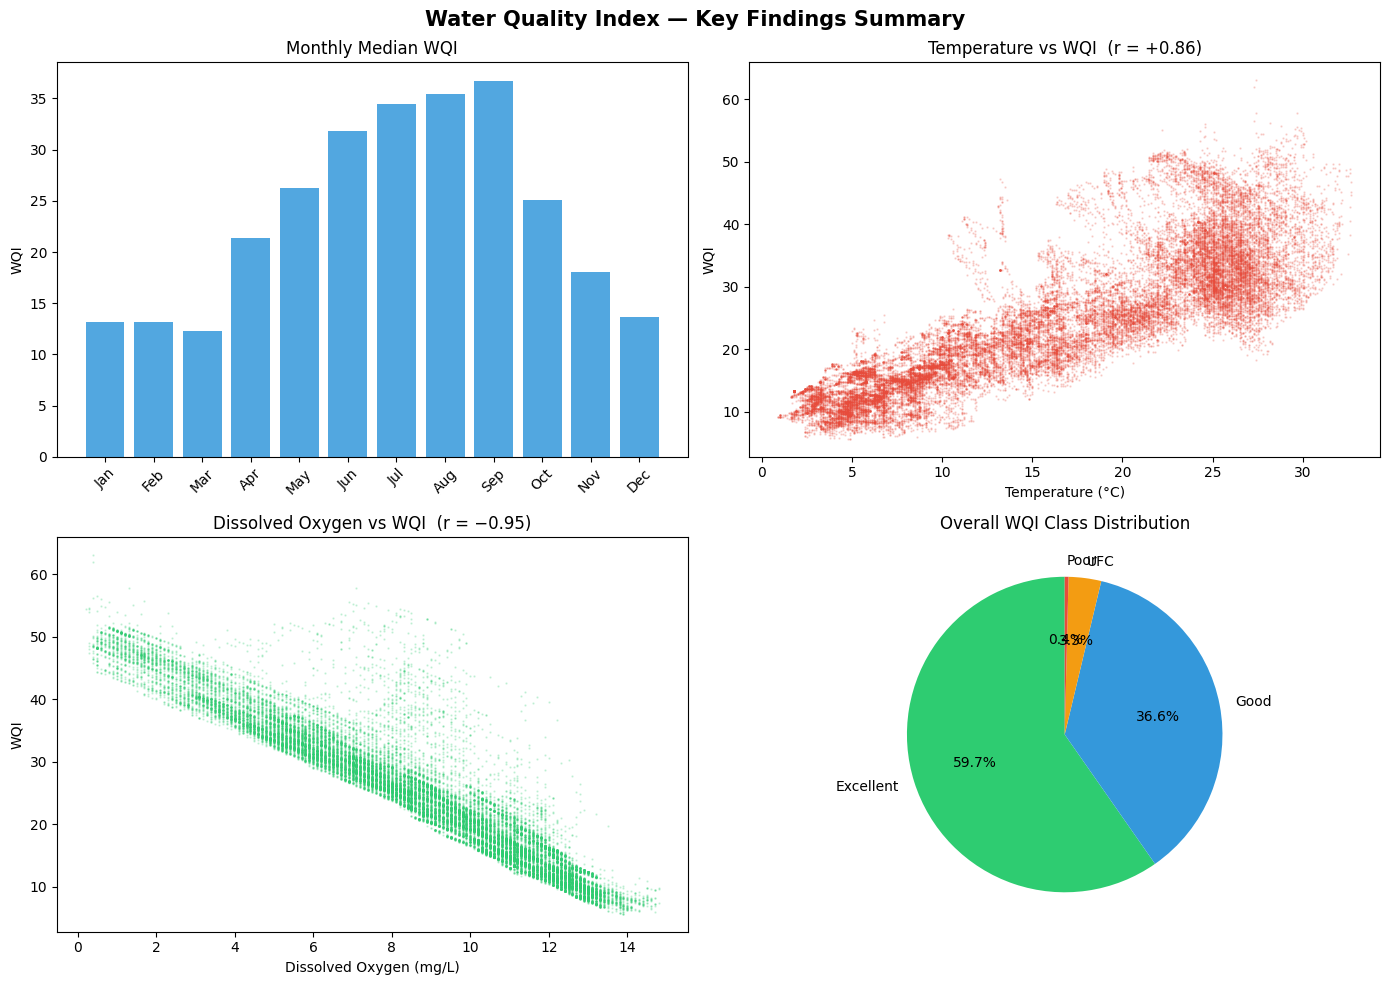

In [32]:
# ── CELL 9: MANAGER SUMMARY — 1 chart with the full story ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Water Quality Index — Key Findings Summary', fontsize=15, fontweight='bold')

# Top-left: monthly WQI bar
ax = axes[0][0]
m = df.groupby('month')['WQI'].median()
ax.bar(m.index, m.values, color='#3498db', alpha=0.85)
ax.set_xticks(range(1,13)); ax.set_xticklabels(month_labels, rotation=45)
ax.set_title('Monthly Median WQI'); ax.set_ylabel('WQI')

# Top-right: Temp vs WQI scatter
ax = axes[0][1]
ax.scatter(df['Temp'], df['WQI'], s=0.5, alpha=0.2, color='#e74c3c')
ax.set_xlabel('Temperature (°C)'); ax.set_ylabel('WQI')
ax.set_title('Temperature vs WQI  (r = +0.86)')

# Bottom-left: DO vs WQI scatter
ax = axes[1][0]
ax.scatter(df['DO_mgl'], df['WQI'], s=0.5, alpha=0.2, color='#2ecc71')
ax.set_xlabel('Dissolved Oxygen (mg/L)'); ax.set_ylabel('WQI')
ax.set_title('Dissolved Oxygen vs WQI  (r = −0.95)')

# Bottom-right: class pie
ax = axes[1][1]
counts = df['WQI_Class'].value_counts().reindex(class_order)
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=[class_colors[c] for c in counts.index], startangle=90)
ax.set_title('Overall WQI Class Distribution')

plt.tight_layout()
plt.savefig('p0_manager_summary.png', dpi=150, bbox_inches='tight')
plt.show()